# 01 — Data Exploration
**Project:** ViT Reliability & Explainability Under Medical Distribution Shift
**Author:** Sosna Worku

**Goal:** Explore NIH ChestX-ray14 — class distribution, patient stats, sample images, bounding boxes.

---
Run all cells top to bottom every new Colab session.

## 0. Setup — Run every session

In [1]:
import os, sys

REPO_PATH = '/content/vit-medical-shift'
GITHUB    = 'https://github.com/sossyh/vit-medical-shift.git'

if os.path.exists(REPO_PATH):
    os.system(f'git -C {REPO_PATH} pull origin main')
else:
    os.system(f'git clone {GITHUB} {REPO_PATH}')

sys.path.insert(0, REPO_PATH)
print('Repo ready!')

Repo ready!


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


In [3]:
!pip install -q timm torchmetrics grad-cam einops pyyaml
print('Packages ready!')

Packages ready!


In [4]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

GPU: Tesla T4


## 1. Paths

In [5]:
DRIVE_ROOT = '/content/drive/MyDrive/data/nih'
CSV_PATH   = f'{DRIVE_ROOT}/Data_Entry_2017.csv'
BBOX_PATH  = f'{DRIVE_ROOT}/BBox_List_2017.csv'
IMG_DIR    = f'{DRIVE_ROOT}/images'

print('CSV exists  :', os.path.exists(CSV_PATH))
print('BBox exists :', os.path.exists(BBOX_PATH))
print('Images dir  :', os.path.exists(IMG_DIR))

# Safe image count — won't crash if Drive is slow
try:
    n = len(os.listdir(IMG_DIR))
    print(f'Images found: {n:,}')
except OSError:
    print('Images dir exists but Drive is slow — remount and retry')
    print('Run: from google.colab import drive; drive.mount("/content/drive", force_remount=True)')

CSV exists  : True
BBox exists : True
Images dir  : True
Images found: 94,875


## 2. Load & Inspect CSV

In [6]:
import pandas as pd
import numpy as np
from src.utils import NIH_LABELS

df = pd.read_csv(CSV_PATH)
print('Total images    :', len(df))
print('Unique patients :', df['Patient ID'].nunique())
print('\nGender:')
print(df['Patient Gender'].value_counts())
print('\nAge stats:')
print(df['Patient Age'].describe())
df.head()

Total images    : 112120
Unique patients : 30805

Gender:
Patient Gender
M    63340
F    48780
Name: count, dtype: int64

Age stats:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## 3. Class Distribution

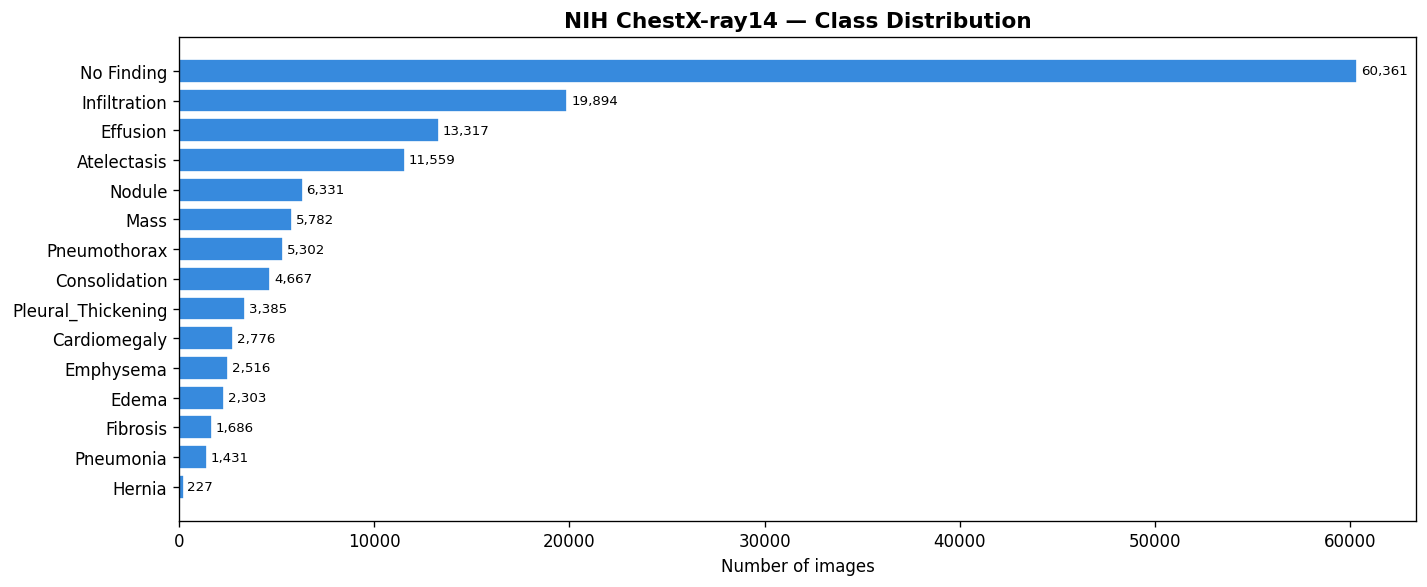

Saved!


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Count each label
label_counts = {}
for label in NIH_LABELS:
    label_counts[label] = df['Finding Labels'].str.contains(label).sum()
label_counts['No Finding'] = df['Finding Labels'].str.contains('No Finding').sum()
label_counts = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(list(label_counts.keys()), list(label_counts.values()),
               color='#378ADD', edgecolor='white')
ax.set_xlabel('Number of images')
ax.set_title('NIH ChestX-ray14 — Class Distribution', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, label_counts.values()):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()

os.makedirs(f'{REPO_PATH}/results/figures', exist_ok=True)
plt.savefig(f'{REPO_PATH}/results/figures/class_distribution.png', dpi=150)
plt.show()
print('Saved!')

## 4. Multi-label Distribution

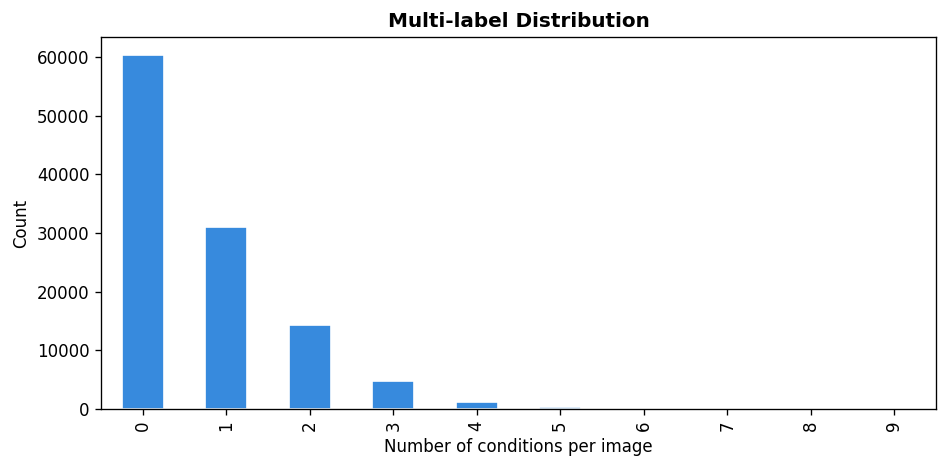

In [8]:
df['n_labels'] = df['Finding Labels'].apply(
    lambda x: 0 if x == 'No Finding' else len(x.split('|'))
)

fig, ax = plt.subplots(figsize=(8, 4))
df['n_labels'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#378ADD', edgecolor='white'
)
ax.set_xlabel('Number of conditions per image')
ax.set_ylabel('Count')
ax.set_title('Multi-label Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPO_PATH}/results/figures/multilabel_dist.png', dpi=150)
plt.show()

## 5. Sample Images

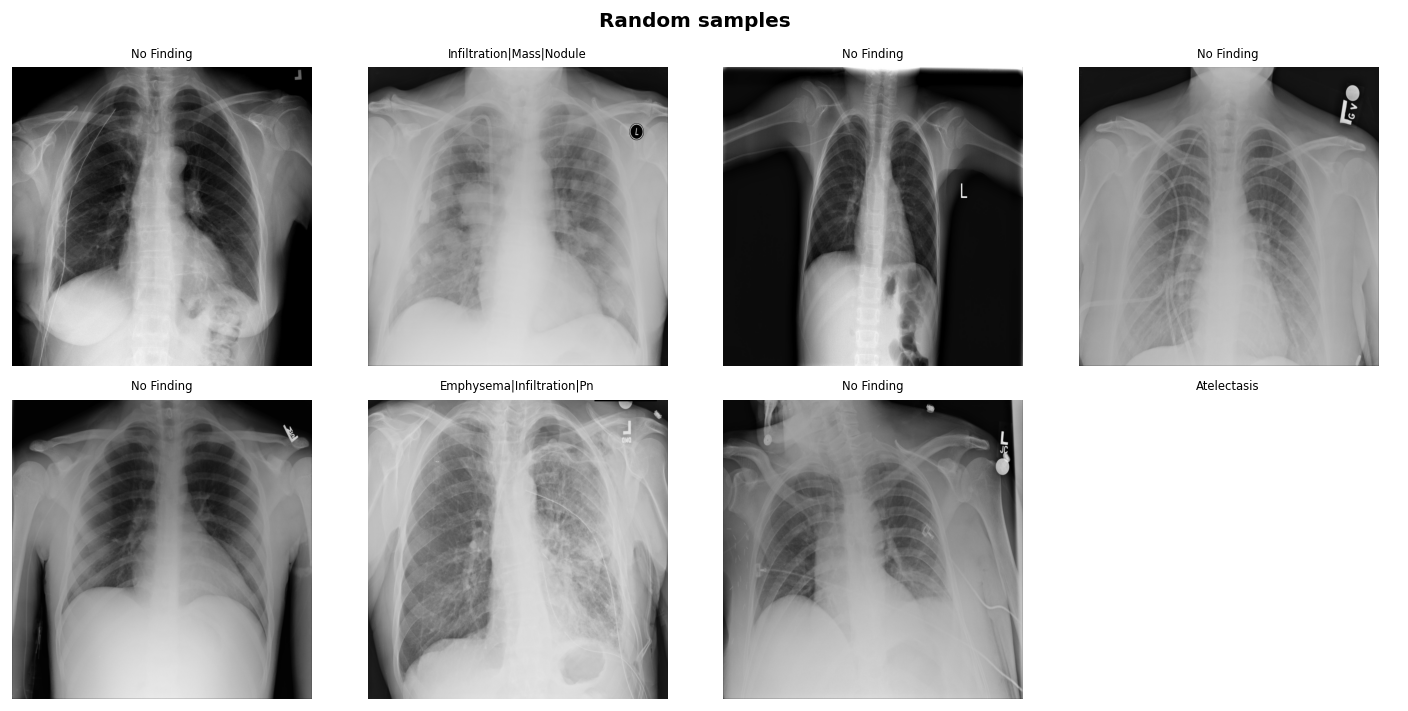

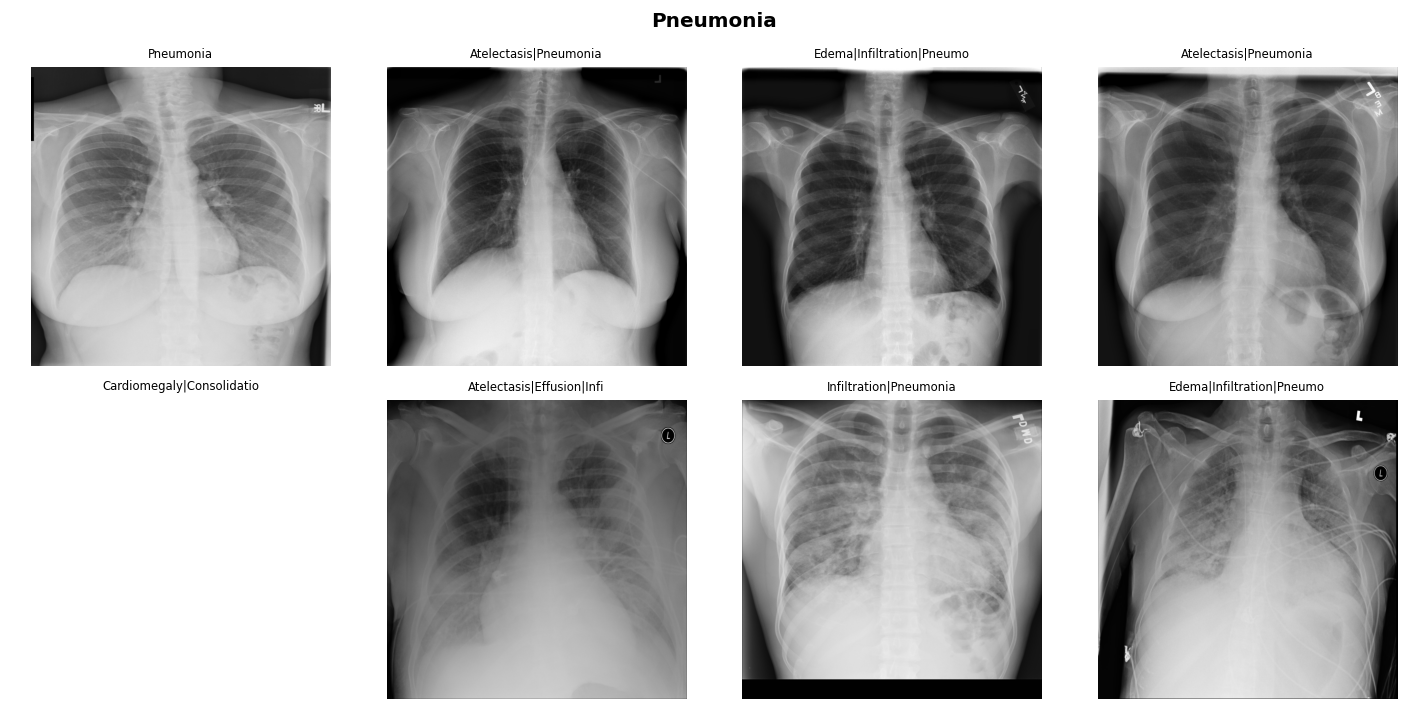

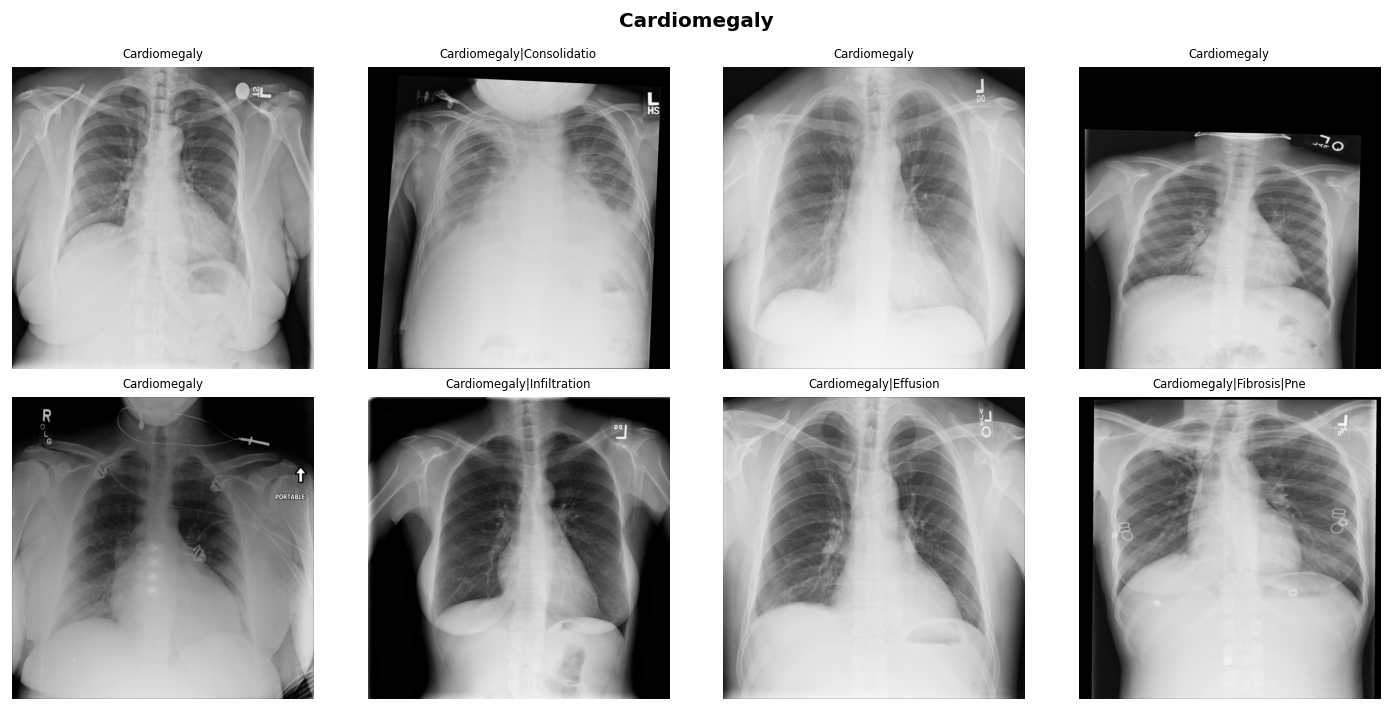

In [9]:
from PIL import Image
from src.dataset import NIHChestDataset, get_transforms

def show_samples(df, img_dir, label=None, n=8, cols=4):
    subset = (
        df[df['Finding Labels'].str.contains(label)].sample(n, random_state=42)
        if label else df.sample(n, random_state=42)
    )
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(img_dir, row['Image Index'])
        if os.path.exists(img_path):
            axes[i].imshow(Image.open(img_path).convert('RGB'), cmap='gray')
        axes[i].set_title(row['Finding Labels'][:25], fontsize=7)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(label or 'Random samples', fontsize=12, fontweight='bold')
    plt.tight_layout()
    name = label.replace(' ', '_') if label else 'random'
    plt.savefig(f'{REPO_PATH}/results/figures/samples_{name}.png', dpi=150)
    plt.show()

show_samples(df, IMG_DIR)
show_samples(df, IMG_DIR, label='Pneumonia')
show_samples(df, IMG_DIR, label='Cardiomegaly')

## 6. Bounding Boxes (used for XAI evaluation in Week 3)

In [10]:
bbox_df = pd.read_csv(BBOX_PATH)
print('BBox shape:', bbox_df.shape)
print('\nFindings with bounding boxes:')
print(bbox_df['Finding Label'].value_counts())
bbox_df.head()

BBox shape: (984, 9)

Findings with bounding boxes:
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64


,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


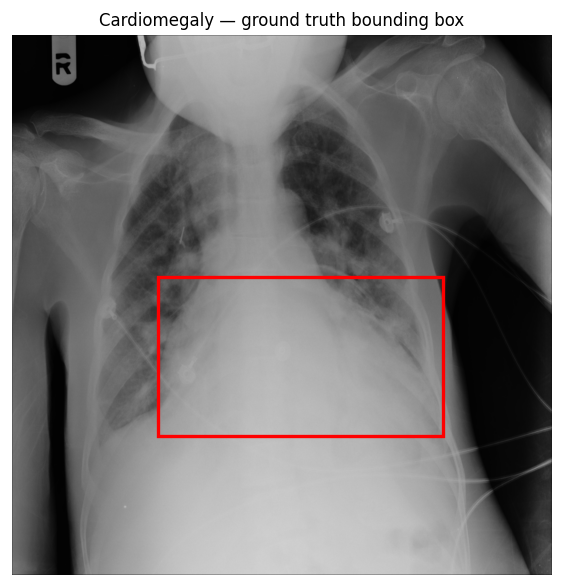

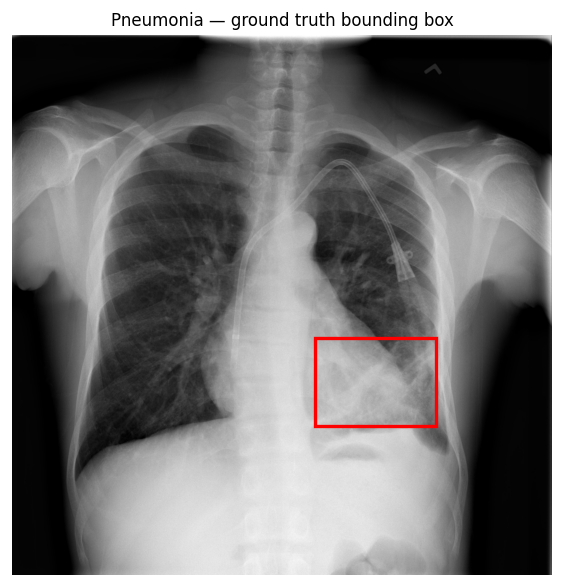

In [11]:
import matplotlib.patches as patches

def show_with_bbox(bbox_df, img_dir, finding='Cardiomegaly'):
    row = bbox_df[bbox_df['Finding Label'] == finding].iloc[0]
    img_path = os.path.join(img_dir, row['Image Index'])
    if not os.path.exists(img_path):
        print('Image not found.')
        return
    img = Image.open(img_path).convert('RGB')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap='gray')

    # correct column names with brackets
    x  = row['Bbox [x']
    y  = row['y']
    w  = row['w']
    h  = row['h]']

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.set_title(f'{finding} — ground truth bounding box', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{REPO_PATH}/results/figures/bbox_{finding}.png', dpi=150)
    plt.show()

show_with_bbox(bbox_df, IMG_DIR, 'Cardiomegaly')
show_with_bbox(bbox_df, IMG_DIR, 'Pneumonia')

## 7. Test DataLoader from src/dataset.py

In [12]:
from src.dataset import get_nih_loaders
from src.utils import get_device

device = get_device()

train_loader, val_loader = get_nih_loaders(
    csv_path   = CSV_PATH,
    img_dir    = IMG_DIR,
    batch_size = 8,
    subset     = 0.01,
    num_workers= 0      # ← fix: 0 workers for Google Drive
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

# Test one batch
images, labels, names = next(iter(train_loader))
print(f'Image shape   : {images.shape}')
print(f'Label shape   : {labels.shape}')
print(f'Sample file   : {names[0]}')

Using GPU: Tesla T4
Train batches : 112
Val batches   : 29
Image shape   : torch.Size([8, 3, 224, 224])
Label shape   : torch.Size([8, 14])
Sample file   : 00011988_001.png


## 8. Save Summary & Push to GitHub

In [25]:
import os
import pandas as pd
from google.colab import files

# ---------------- SAVE METRICS ----------------

summary = pd.DataFrame({
    'label': list(label_counts.keys()),
    'count': list(label_counts.values()),
    'prevalence': [v / len(df) for v in label_counts.values()]
})

save_dir = f'{REPO_PATH}/results/metrics'
os.makedirs(save_dir, exist_ok=True)

file_path = f'{save_dir}/class_distribution.csv'
summary.to_csv(file_path, index=False)

print('Saved class_distribution.csv!')

# ---------------- DOWNLOAD FILE ----------------

files.download(file_path)

# ---------------- OPTIONAL: PUSH TO GITHUB ----------------

os.chdir(REPO_PATH)

!git config user.email "sosworkuacha@gmail.com"
!git config user.name "Sosna Worku"

!git add results/figures/ results/metrics/
!git commit -m "week 1: data exploration figures and metrics" || echo "Nothing to commit"
!git push origin main

Saved class_distribution.csv!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

On branch main
nothing to commit, working tree clean
Nothing to commit
remote: Permission to sossyh/vit-medical-shift.git denied to sossyh.
fatal: unable to access 'https://github.com/sossyh/vit-medical-shift.git/': The requested URL returned error: 403
